# Prioritizing CTR Review with a Small Search Model
## FlyRank Machine Learning Capstone — Ahmed Raza

### Abstract
This study asks whether a small model improves prediction of later click-through rate while supporting a transparent queue of pages for human review.
It uses 9,841,378 daily records from the March 2026 FlyRank warehouse partition, with March 1–15 features and March 16–31 observed outcomes.
Five past-only features feed fixed Ridge and gradient-boosting candidates, compared with persistence and a position-band reference on disjoint client groups.
Ridge, selected on validation clients, reduces held-out-client MAE from 0.1675 to 0.1410 CTR percentage points, while top-queue proxy precision ties the simpler baseline.
The results support cautious review prioritization and improved CTR estimation within this slice, not a claim that edits cause additional clicks.

## 1. Problem and decision

A content specialist with limited review time needs to know which visible pages deserve a closer look. Low aggregate CTR alone is not enough: query intent, search-result layout and position can differ. The deliverable is an explainable review queue and an honest comparison of a simple forecast with learned models. A false positive wastes review time and may encourage a harmful unnecessary edit; a false negative overlooks a useful review.

## 2. Data and field contract

Source: `FlyRank/internship-warehouse`, release v20260703, March 2026 daily partition. One raw row is a date × client × content item. Raw client names, URLs, titles and queries are unavailable and are not inferred. The data-contract notebook verifies the grain, date span and `IS TRUE` availability checks.

Features use March 1–15 only: observed CTR, log impression volume, impression-weighted valid position, impression coefficient of variation, and zero-click-day fraction. Pages need 500+ past impressions, all 15 past dates available and valid mean position 1–20. Evaluation additionally needs 500+ later impressions and all 16 later dates available; that condition is never used to choose the operational queue. GA4 and query-table fields are excluded.

## 3. Frozen methodology

- **Target:** observed March 16–31 CTR, `100 × clicks / impressions`, in percentage points. No recreated flag or opportunity score is a model target.
- **Split:** hash client pseudonyms into five groups: 2–4 training, 1 validation, 0 final test. IDs are never features. Feature and outcome windows do not overlap.
- **Baselines:** persistence predicts later CTR equals past CTR; a training-client position-band median is a second reference.
- **Candidates:** standardized Ridge (`alpha=1`) and histogram gradient boosting (100 iterations, 15 leaves, 40 minimum samples per leaf, L2=1, no early stopping). Random seed 42. No hyperparameter search.
- **Selection:** lowest validation-client page-level MAE, allowing a baseline to win. Freeze before test. Report page MAE, impression-weighted MAE and equal-client macro MAE on identical rows.
- **Uncertainty:** 2,000 paired client-bootstrap draws for the selected-minus-persistence macro MAE difference. Only six test clients make this interval exploratory.
- **Queue:** positive training-reference CTR gap × past impressions / 100. Future-CTR-below-reference checks at K=10 and 50 are directional proxies, not independent actionability labels.
- **Leakage:** ML-04 shows the invalid near-perfect score from directly supplying the target, deletes the column and reruns the honest five-input model. Final-test clients are excluded from that exercise.

## 4. Executed study

The following cell reruns the complete frozen pipeline from the approved local partition. No raw daily dataframe is loaded into pandas.

,partition,pages,clients
0,train,7687,16
1,validation,7932,5
2,test,10153,6


Feature pages: 28862 Evaluation pages: 25772 Outcome-coverage exclusions: 3090
Selected using validation only: Ridge


,method,pages,clients,mae_pp,impression_weighted_mae_pp,client_macro_mae_pp
0,Persistence,7932,5,0.15355,0.12446,0.18473
1,Position reference,7932,5,0.23954,0.23065,0.27436
2,Ridge,7932,5,0.13498,0.11239,0.16180
3,Gradient boosting,7932,5,0.13564,0.10939,0.17858


,method,pages,clients,mae_pp,impression_weighted_mae_pp,client_macro_mae_pp
0,Persistence,10153,6,0.16751,0.14644,0.17514
1,Position reference,10153,6,0.24107,0.23157,0.24919
2,Ridge,10153,6,0.14102,0.11925,0.14819
3,Gradient boosting,10153,6,0.14130,0.11512,0.14793


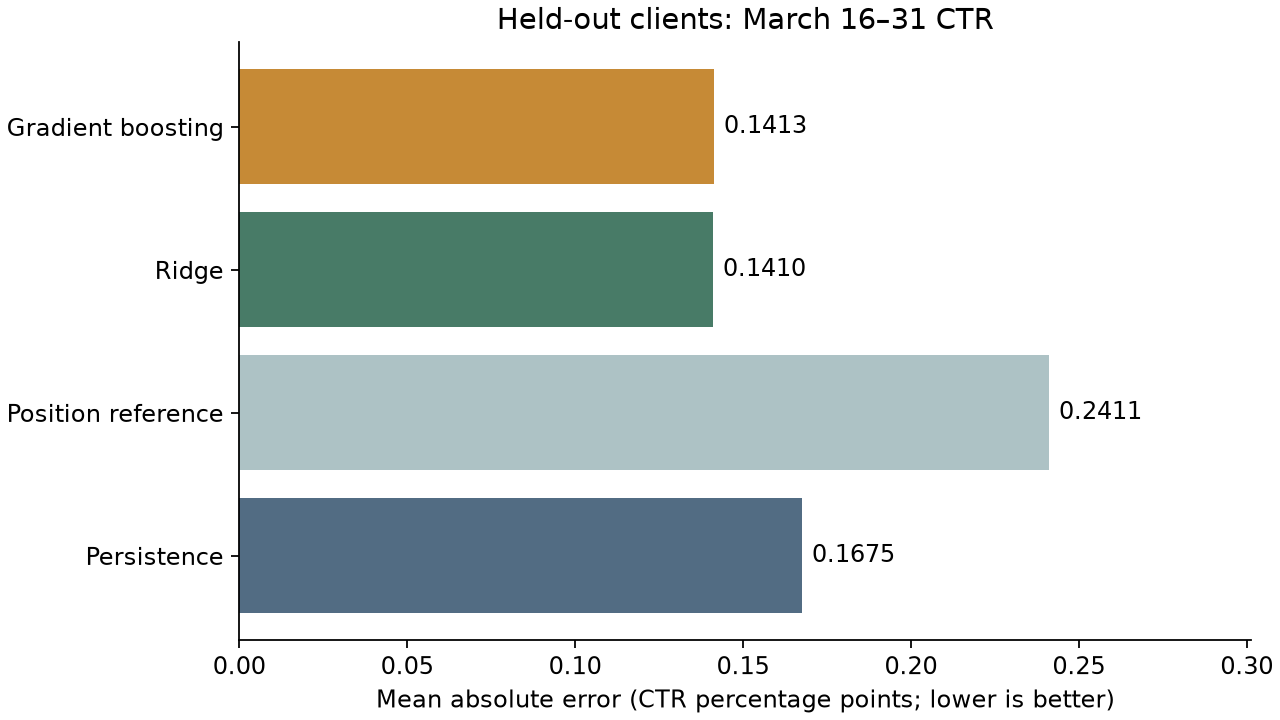

In [1]:
from pathlib import Path
import sys,json
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'work/run_study.py').is_file())
sys.path.insert(0,str(ROOT/'work'))
import run_study
import pandas as pd
from IPython.display import display,Image
results=run_study.run()
display(pd.DataFrame(results['split']))
print('Feature pages:',results['feature_pages'],'Evaluation pages:',results['evaluation_pages'],
      'Outcome-coverage exclusions:',results['excluded_from_evaluation'])
print('Selected using validation only:',results['selected_on_validation'])
display(pd.DataFrame(results['validation']).round(5))
display(pd.DataFrame(results['test']).round(5))
display(Image(filename=str(ROOT/'work/figures/test_error.png')))


## 5. Results and uncertainty

Ridge improves the headline test MAE by **15.82%** relative to persistence (0.167515 → 0.141015 percentage points). Impression-weighted error also falls, from 0.146436 to 0.119248 pp. The test set has 10,153 pages but only six clients: pages are not independent evidence of thousands of unrelated domains. The paired client-bootstrap difference is approximately -0.0501 to -0.0082 pp; it describes uncertainty across these clients, not across future months.

The boosted candidate has slightly lower impression-weighted error but higher headline page MAE than Ridge. The selection rule was page MAE on validation, so Ridge remains selected; the test results are not used to change methods.

In [2]:
print('95% paired client-bootstrap interval (selected minus persistence; negative favors selected):',
      results['selected_minus_persistence_client_macro_mae_ci95_pp'])
display(pd.DataFrame(results['ranking_proxy']).round(5))
display(pd.DataFrame(results['sensitivity']).round(5))


95% paired client-bootstrap interval (selected minus persistence; negative favors selected): [-0.050101913160541404, -0.0082128676338617]


,method,k,future_below_reference_fraction,base_rate,positive_score_items
0,Persistence,10,1.0,0.74146,10
1,Persistence,50,1.0,0.74146,50
2,Ridge,10,1.0,0.74146,10
3,Ridge,50,1.0,0.74146,50
4,Gradient boosting,10,1.0,0.74146,10
5,Gradient boosting,50,1.0,0.74146,50


,outcome_impression_threshold,pages,selected_mae_pp,persistence_mae_pp
0,500,10153,0.14102,0.16751
1,1000,7435,0.12942,0.15798
2,3000,3243,0.11486,0.14267


Both the rule and the learned candidates achieve 1.00 at K=10 and K=50 for **future CTR below the training-band reference**, against a 0.74146 base rate. This proxy is easy at the queue head and does not distinguish better edits. There is no demonstrated ranking advantage, so retain the transparent baseline queue and use Ridge only for improved CTR estimation. Independent actionability precision remains unmeasured.

Increasing the outcome-volume threshold to 1,000 or 3,000 changes the evaluated population; the sensitivity table is descriptive and is not a new selection exercise.

## 6. Error analysis and plausible signals

The boosted candidate's largest permutation effects are past CTR, zero-click fraction and impression volume: each describes click behavior or measurement stability before the outcome window. This does not identify causal search ranking factors. Ridge coefficients below are on standardized inputs and should not be interpreted independently when features are correlated.

,feature,mae_increase_pp,std_pp
0,past_ctr,0.092487,0.001686
1,zero_click_fraction,0.008269,0.000763
2,log_impressions,0.006616,0.000585
3,impression_cv,0.000587,0.000279
4,mean_position,0.000099,0.000315


,Ridge coefficient per input SD
past_ctr,0.276964
log_impressions,-0.019623
mean_position,0.011712
impression_cv,0.013615
zero_click_fraction,-0.041574


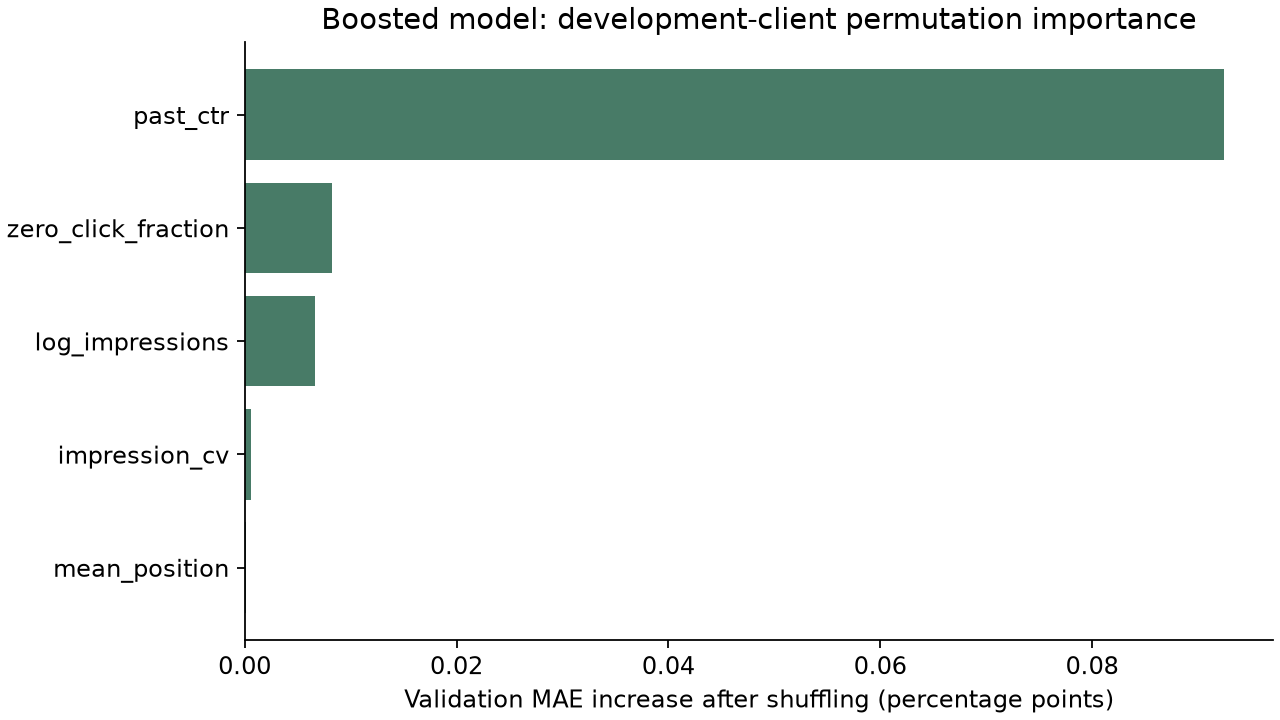

,position_band,n,mae_pp
0,1-3,2173,0.16031
1,>3-10,7291,0.13430
2,>10-20,689,0.15124


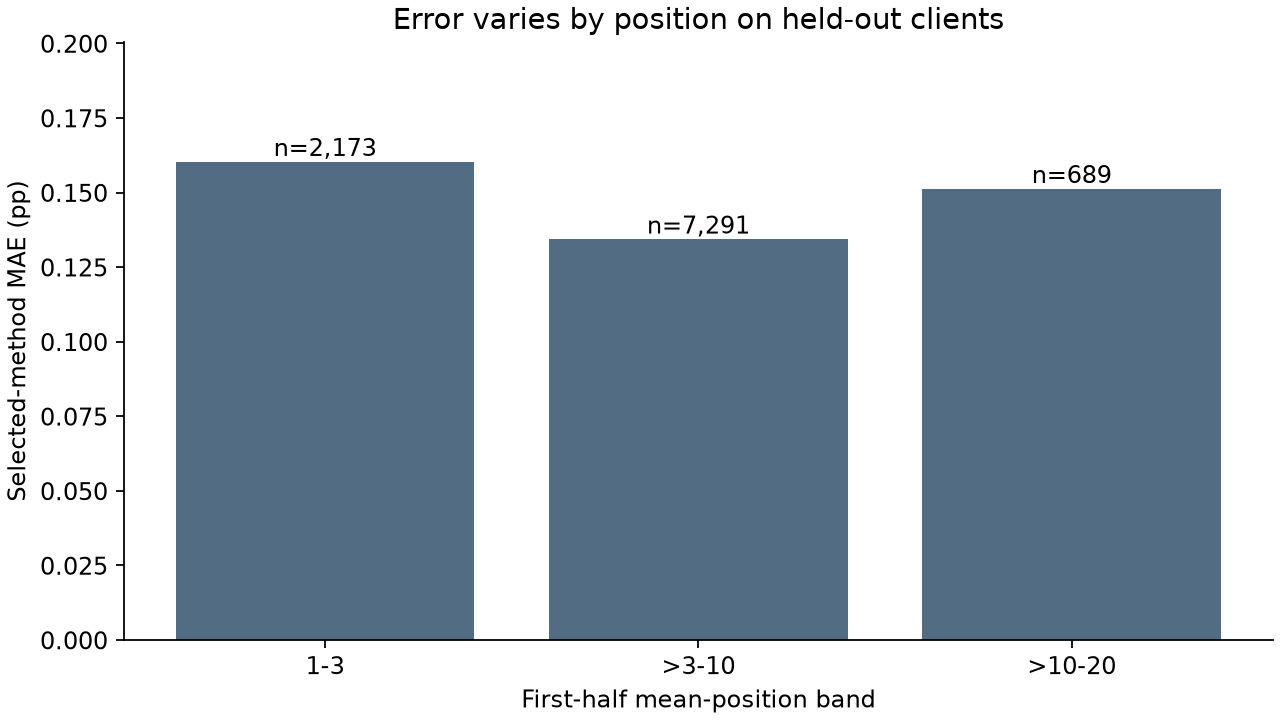

,content_hash_id,past_ctr,future_ctr,prediction,abs_error_pp,mean_position
0,content_efa152da7d9e5184,5.88235,1.38741,3.79323,2.40583,3.43256
1,content_4a1e4558893cfb77,0.96996,2.96610,0.79805,2.16806,17.43163
2,content_6d8726c13216585f,1.16505,2.89855,0.83824,2.06031,1.32816


In [3]:
display(pd.DataFrame(results['importance']).round(6))
display(pd.Series(results['ridge_standardized_coefficients'],name='Ridge coefficient per input SD').to_frame())
display(Image(filename=str(ROOT/'work/figures/feature_importance.png')))
display(pd.DataFrame(results['errors_by_position']).round(5))
display(Image(filename=str(ROOT/'work/figures/error_by_position.png')))
display(pd.DataFrame(results['largest_errors']))


The first large-error example falls from 5.88% to 1.39% CTR, while the model predicts 3.79%; it misses the magnitude of a sharp reversal. The next two rise from about 0.97% and 1.17% to about 2.97% and 2.90%; a past-window model cannot reliably anticipate those jumps from these five signals. Query mix, transient demand and changing search results are plausible explanations, not measured causes.

## 7. Limitations

One month cannot establish seasonal or later-month generalization. Coverage and minimum-volume filters select established, sufficiently measured pages and exclude 3,090 otherwise feature-eligible pages from outcome evaluation. Client sizes differ, and only six appear in the final test. An aggregate position cannot control country, device, intent or search-result features. Data reporting lag is not modeled. A higher review score is not proof of a defective snippet or recoverable clicks. No intervention, live-page review, causal design or independent actionability labels are available. The source is a pseudonymized teaching release; results should not be generalized to all search traffic.

## 8. Ranked recommendations

Keep the simple rule: review search intent and snippets, check query/device context if authorized data later becomes available, and record a human decision before editing. Preserve a page unchanged when its CTR is appropriate for its intent. These ten recommendations are numeric evidence reviews, not claims that the live pages were inspected.

In [4]:
print('Local baseline queue pages:',results['queue_pages'])
display(pd.DataFrame(results['top10']))


Local baseline queue pages: 18445


,rank,content_id,action,evidence,caveat
0,1,content_7c6373141eae744a,Review search intent and snippet,"CTR 0.059% vs reference 0.391%; 86,860 impress...",Large exposure can magnify a small gap; check ...
1,2,content_8e1334d6356668e3,Review search intent and snippet,"CTR 0.002% vs reference 0.391%; 58,553 impress...",Search-result answers may explain low CTR with...
2,3,content_65c75874a23fca87,Review search intent and snippet,"CTR 0.027% vs reference 0.391%; 55,680 impress...",A broad position band does not control device ...
3,4,content_acbcc847f8996314,Review search intent and snippet,"CTR 0.159% vs reference 0.391%; 83,715 impress...",Daily average rank can hide query-level positi...
4,5,content_34a70fea29d15f24,Review search intent and snippet,"CTR 0.024% vs reference 0.284%; 73,639 impress...",Reference-client medians may not transfer to t...
5,6,content_945d6ff91386c817,Review search intent and snippet,"CTR 0.004% vs reference 0.391%; 49,314 impress...",Informational intent may justify low CTR.
6,7,content_1642f339bd6e7c8d,Review search intent and snippet,"CTR 0.034% vs reference 0.391%; 52,378 impress...",A few highly exposed queries can dominate the ...
7,8,content_f6116743b00afc2d,Review search intent and snippet,"CTR 0.016% vs reference 0.391%; 49,619 impress...",A short event can dominate this 15-day window.
8,9,content_b99ea6861864dea5,Review search intent and snippet,"CTR 0.202% vs reference 0.391%; 91,474 impress...",Changing an appropriate title can reduce perfo...
9,10,content_36fc1ee501ec072d,Review search intent and snippet,"CTR 0.024% vs reference 0.391%; 46,199 impress...",Measurement coverage does not guarantee compar...


## 9. Reproducibility

Run `python work/execute_study_notebooks.py` after following `work/REPRODUCE.md`. The local dataset is excluded from Git; the notebook regenerates metrics JSONs, charts and the ignored baseline CSV. SHA-256 and exact Python/library versions are recorded below. The repository contains the five-feature transformation and complete model script.

Repository: https://github.com/7-ARK/flyranks_week1_notebook_01

## 10. Acknowledgments and data credit

Built on the [FlyRank ML Internship dataset](https://flyrank.ai). Dataset release: [FlyRank/internship-warehouse](https://huggingface.co/datasets/FlyRank/internship-warehouse), v20260703. This work uses March's partition and respects its research/education and non-redistribution terms.

In [5]:
print('Dataset SHA-256:',results['data_sha256'])
print('Python:',results['python'])
display(pd.Series(results['versions'],name='version').to_frame())


Dataset SHA-256: 6ebd367f05932238df05b193f9cfb9cc7839d7856b65ef74b5a122d5fadef589
Python: 3.11.9


,version
duckdb,1.5.5
pandas,3.0.5
numpy,2.4.6
scikit-learn,1.9.0
matplotlib,3.11.1
